<a href="https://colab.research.google.com/github/mitshiabopm-bot/Bright-TV/blob/main/Oil_Seeds.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [94]:
df=pd.read_excel('/content/oil_seeds_punjab.csv.xlsx')
df

,Year,Crop_Name,Crop_Type,District_Name,Area_Hectares,Production_Tonnes,Yield_Kg_Per_Hectare,Season,Temperature_Celsius_Avg,Rainfall_MM,Irrigation_Requirement_MM,Soil_Type,Market_Price_PKR_Per_Kg,Export_Status,Quality_Grade,Purity_Percent
0,2020,Sunflower,Oilseed,Okara,12500,18750,1500,Spring,32.5,425,250,Sandy Loam,65,Exported,A,96.2
1,2020,Sunflower,Oilseed,Jhang,11200,16240,1450,Spring,31.8,390,260,Loamy,63,Exported,A,95.8
2,2020,Sunflower,Oilseed,Faisalabad,15000,22500,1500,Spring,33.2,410,240,Sandy Loam,65,Exported,A,96.5
3,2020,Sunflower,Oilseed,Sahiwal,8900,11680,1312,Spring,32.1,380,270,Loamy,62,Local Market,B,94.2
4,2020,Sunflower,Oilseed,Gujranwala,7500,9750,1300,Spring,31.5,415,265,Clay Loam,60,Local Market,B,93.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,2025,Rape Seed,Oilseed,Sialkot,5000,4000,800,Winter,19.7,750,150,Sandy Loam,152,Exported,A,99.7
74,2025,Rape Seed,Oilseed,Gujrat,3500,2800,800,Winter,19.4,720,160,Loamy,148,Local Market,B,98.3
75,2025,Gram,Pulse,Okara,11000,10450,950,Winter,21.0,670,120,Sandy Loam,128,Exported,A,98.6
76,2025,Gram,Pulse,Kasur,9400,8930,950,Winter,21.3,680,110,Loamy,129,Exported,A,98.9


In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Year                       78 non-null     int64  
 1   Crop_Name                  78 non-null     object 
 2   Crop_Type                  78 non-null     object 
 3   District_Name              78 non-null     object 
 4   Area_Hectares              78 non-null     int64  
 5   Production_Tonnes          78 non-null     int64  
 6   Yield_Kg_Per_Hectare       78 non-null     int64  
 7   Season                     78 non-null     object 
 8   Temperature_Celsius_Avg    78 non-null     float64
 9   Rainfall_MM                78 non-null     int64  
 10  Irrigation_Requirement_MM  78 non-null     int64  
 11  Soil_Type                  78 non-null     object 
 12  Market_Price_PKR_Per_Kg    78 non-null     int64  
 13  Export_Status              78 non-null     object 
 

In [96]:
df.isnull()

,Year,Crop_Name,Crop_Type,District_Name,Area_Hectares,Production_Tonnes,Yield_Kg_Per_Hectare,Season,Temperature_Celsius_Avg,Rainfall_MM,Irrigation_Requirement_MM,Soil_Type,Market_Price_PKR_Per_Kg,Export_Status,Quality_Grade,Purity_Percent
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
74,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
75,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
76,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [97]:
df.isnull().sum()

,0
Year,0
Crop_Name,0
Crop_Type,0
District_Name,0
Area_Hectares,0
Production_Tonnes,0
Yield_Kg_Per_Hectare,0
Season,0
Temperature_Celsius_Avg,0
Rainfall_MM,0


In [98]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
73,False
74,False
75,False
76,False


In [99]:
df.duplicated().sum()

np.int64(0)

In [100]:
df["Year"].unique()

array([2020, 2021, 2022, 2023, 2024, 2025])

In [101]:
df["Crop_Name"].unique()

array(['Sunflower', 'Cotton Seed', 'Rape Seed', 'Gram'], dtype=object)

In [102]:
df["Crop_Type"].unique()

array(['Oilseed', 'Pulse'], dtype=object)

In [103]:
df["District_Name"].unique()

array(['Okara', 'Jhang', 'Faisalabad', 'Sahiwal', 'Gujranwala', 'Multan',
       'Bahawalpur', 'Vehari', 'Sialkot', 'Gujrat', 'Kasur'], dtype=object)

In [104]:
df["Season"].unique()

array(['Spring', 'Summer', 'Winter'], dtype=object)

In [105]:
df["Soil_Type"].unique()

array(['Sandy Loam', 'Loamy', 'Clay Loam', 'Sandy'], dtype=object)

In [106]:
df["Export_Status"].unique()

array(['Exported', 'Local Market'], dtype=object)

In [107]:
df["Quality_Grade"].unique()

array(['A', 'B'], dtype=object)

**Adding a column Revenue which is per Kg**

In [108]:
df['Revenue'] = (df['Production_Tonnes'] * df['Market_Price_PKR_Per_Kg']) / 1000
df

,Year,Crop_Name,Crop_Type,District_Name,Area_Hectares,Production_Tonnes,Yield_Kg_Per_Hectare,Season,Temperature_Celsius_Avg,Rainfall_MM,Irrigation_Requirement_MM,Soil_Type,Market_Price_PKR_Per_Kg,Export_Status,Quality_Grade,Purity_Percent,Revenue
0,2020,Sunflower,Oilseed,Okara,12500,18750,1500,Spring,32.5,425,250,Sandy Loam,65,Exported,A,96.2,1218.75
1,2020,Sunflower,Oilseed,Jhang,11200,16240,1450,Spring,31.8,390,260,Loamy,63,Exported,A,95.8,1023.12
2,2020,Sunflower,Oilseed,Faisalabad,15000,22500,1500,Spring,33.2,410,240,Sandy Loam,65,Exported,A,96.5,1462.50
3,2020,Sunflower,Oilseed,Sahiwal,8900,11680,1312,Spring,32.1,380,270,Loamy,62,Local Market,B,94.2,724.16
4,2020,Sunflower,Oilseed,Gujranwala,7500,9750,1300,Spring,31.5,415,265,Clay Loam,60,Local Market,B,93.8,585.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,2025,Rape Seed,Oilseed,Sialkot,5000,4000,800,Winter,19.7,750,150,Sandy Loam,152,Exported,A,99.7,608.00
74,2025,Rape Seed,Oilseed,Gujrat,3500,2800,800,Winter,19.4,720,160,Loamy,148,Local Market,B,98.3,414.40
75,2025,Gram,Pulse,Okara,11000,10450,950,Winter,21.0,670,120,Sandy Loam,128,Exported,A,98.6,1337.60
76,2025,Gram,Pulse,Kasur,9400,8930,950,Winter,21.3,680,110,Loamy,129,Exported,A,98.9,1151.97


In [109]:
df["Revenue"].max()

4602.0

In [110]:
df["Revenue"].min()

198.24

In [111]:
df["Revenue"].mean()

np.float64(1411.678205128205)

In [126]:
df['Temperature_Celsius_Avg'].min()

17.2

In [127]:
df['Temperature_Celsius_Avg'].max()

36.7

In [128]:
df['Temperature_Celsius_Avg'].mean()

np.float64(28.27307692307692)

In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [130]:
# Define the conditions for each temperature bucket
conditions = [
    (df['Temperature_Celsius_Avg'] >= 17.2) & (df['Temperature_Celsius_Avg'] <= 23.7),
    (df['Temperature_Celsius_Avg'] >= 23.8) & (df['Temperature_Celsius_Avg'] <= 30.3),
    (df['Temperature_Celsius_Avg'] > 30.3)
]

# Define the corresponding labels for each bucket
choices = ['low', 'medium', 'high']

# Create the new 'Temperature_Bucket' column using numpy.select
df['Temperature_Bucket'] = np.select(conditions, choices, default='unknown')

# Display the first few rows with the new column and its value counts to verify
display(df[['Temperature_Celsius_Avg', 'Temperature_Bucket']].head())
display(df['Temperature_Bucket'].value_counts())

,Temperature_Celsius_Avg,Temperature_Bucket
0,32.5,high
1,31.8,high
2,33.2,high
3,32.1,high
4,31.5,high


,count
Temperature_Bucket,
high,48
low,30


In [131]:
df['Rainfall_MM'].min()

280

In [133]:
df['Rainfall_MM'].max()

750

In [134]:
df['Rainfall_MM'].mean()

np.float64(510.3205128205128)

In [135]:
# Define the conditions for each temperature bucket
conditions = [
    (df['Rainfall_MM'] >= 280) & (df['Rainfall_MM'] <= 498.9),
    (df['Rainfall_MM'] >= 498.9) & (df['Rainfall_MM'] <= 498.9),
    (df['Rainfall_MM'] > 498.9)
]

# Define the corresponding labels for each bucket
choices = ['less', 'medium', 'more']

# Create the new 'Temperature_Bucket' column using numpy.select
df['Rainfall_Bucket'] = np.select(conditions, choices, default='unknown')

# Display the first few rows with the new column and its value counts to verify
display(df[['Rainfall_MM', 'Rainfall_Bucket']].head())
display(df['Rainfall_Bucket'].value_counts())

,Rainfall_MM,Rainfall_Bucket
0,425,less
1,390,less
2,410,less
3,380,less
4,415,less


,count
Rainfall_Bucket,
less,46
more,32


In [136]:
df['Irrigation_Requirement_MM'].min()

100

In [137]:
df['Irrigation_Requirement_MM'].max()

320

In [138]:
df['Irrigation_Requirement_MM'].mean()

np.float64(219.6153846153846)

In [139]:
# Define the conditions for each temperature bucket
conditions = [
    (df['Irrigation_Requirement_MM'] >= 100) & (df['Irrigation_Requirement_MM'] <= 173.3),
    (df['Irrigation_Requirement_MM'] >= 173.3) & (df['Irrigation_Requirement_MM'] <= 246.6),
    (df['Irrigation_Requirement_MM'] > 246.6)
]

# Define the corresponding labels for each bucket
choices = ['less', 'medium', 'more']

# Create the new 'Temperature_Bucket' column using numpy.select
df['Irrigation_Bucket'] = np.select(conditions, choices, default='unknown')

# Display the first few rows with the new column and its value counts to verify
display(df[['Irrigation_Requirement_MM', 'Irrigation_Bucket']].head())
display(df['Irrigation_Bucket'].value_counts())

,Irrigation_Requirement_MM,Irrigation_Bucket
0,250,more
1,260,more
2,240,medium
3,270,more
4,265,more


,count
Irrigation_Bucket,
more,42
less,30
medium,6


In [141]:
df['Purity_Percent'].min()

93.8

In [143]:
df['Purity_Percent'].max()

99.7

In [144]:
df['Purity_Percent'].mean()

np.float64(97.01153846153846)

In [145]:
# Define the conditions for each temperature bucket
conditions = [
    (df['Purity_Percent'] >= 93.8) & (df['Purity_Percent'] <= 95.77),
    (df['Purity_Percent'] >= 95.77) & (df['Purity_Percent'] <= 97.74),
    (df['Purity_Percent'] > 97.74)
]

# Define the corresponding labels for each bucket
choices = ['minimum', 'average', 'maximum']

# Create the new 'Temperature_Bucket' column using numpy.select
df['Purity_Bucket'] = np.select(conditions, choices, default='unknown')

# Display the first few rows with the new column and its value counts to verify
display(df[['Purity_Percent', 'Purity_Bucket']].head())
display(df['Purity_Bucket'].value_counts())

,Purity_Percent,Purity_Bucket
0,96.2,average
1,95.8,average
2,96.5,average
3,94.2,minimum
4,93.8,minimum


,count
Purity_Bucket,
average,41
maximum,23
minimum,14


In [158]:
df['Yield_Kg_Per_Hectare'].min()

800

In [159]:
df['Yield_Kg_Per_Hectare'].max()

2000

In [160]:
df['Yield_Kg_Per_Hectare'].mean()

np.float64(1338.6153846153845)

In [163]:
# Define the conditions for each temperature bucket
conditions = [
    (df['Yield_Kg_Per_Hectare'] >= 800) & (df['Yield_Kg_Per_Hectare'] <= 1200),
    (df['Yield_Kg_Per_Hectare'] >= 1200) & (df['Yield_Kg_Per_Hectare'] <= 1600),
    (df['Yield_Kg_Per_Hectare'] > 1600)
   ]

# Define the corresponding labels for each bucket
choices = ['minimum', 'average', 'maximum']

# Create the new 'Temperature_Bucket' column using numpy.select
df['Yield_Per_Hectare_Bucket'] = np.select(conditions, choices, default='unknown')

# Display the first few rows with the new column and its value counts to verify
display(df[['Yield_Kg_Per_Hectare', 'Yield_Per_Hectare_Bucket']].head())
display(df['Yield_Per_Hectare_Bucket'].value_counts())

,Yield_Kg_Per_Hectare,Yield_Per_Hectare_Bucket
0,1500,average
1,1450,average
2,1500,average
3,1312,average
4,1300,average


,count
Yield_Per_Hectare_Bucket,
average,30
minimum,30
maximum,18


In [165]:
display(df)

,Year,Crop_Name,Crop_Type,District_Name,Area_Hectares,Production_Tonnes,Yield_Kg_Per_Hectare,Season,Temperature_Celsius_Avg,Rainfall_MM,...,Market_Price_PKR_Per_Kg,Export_Status,Quality_Grade,Purity_Percent,Revenue,Temperature_Bucket,Rainfall_Bucket,Irrigation_Bucket,Purity_Bucket,Yield_Per_Hectare_Bucket
0,2020,Sunflower,Oilseed,Okara,12500,18750,1500,Spring,32.5,425,...,65,Exported,A,96.2,1218.75,high,less,more,average,average
1,2020,Sunflower,Oilseed,Jhang,11200,16240,1450,Spring,31.8,390,...,63,Exported,A,95.8,1023.12,high,less,more,average,average
2,2020,Sunflower,Oilseed,Faisalabad,15000,22500,1500,Spring,33.2,410,...,65,Exported,A,96.5,1462.50,high,less,medium,average,average
3,2020,Sunflower,Oilseed,Sahiwal,8900,11680,1312,Spring,32.1,380,...,62,Local Market,B,94.2,724.16,high,less,more,minimum,average
4,2020,Sunflower,Oilseed,Gujranwala,7500,9750,1300,Spring,31.5,415,...,60,Local Market,B,93.8,585.00,high,less,more,minimum,average
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,2025,Rape Seed,Oilseed,Sialkot,5000,4000,800,Winter,19.7,750,...,152,Exported,A,99.7,608.00,low,more,less,maximum,minimum
74,2025,Rape Seed,Oilseed,Gujrat,3500,2800,800,Winter,19.4,720,...,148,Local Market,B,98.3,414.40,low,more,less,maximum,minimum
75,2025,Gram,Pulse,Okara,11000,10450,950,Winter,21.0,670,...,128,Exported,A,98.6,1337.60,low,more,less,maximum,minimum
76,2025,Gram,Pulse,Kasur,9400,8930,950,Winter,21.3,680,...,129,Exported,A,98.9,1151.97,low,more,less,maximum,minimum


In [112]:
Yearly_Revenue = df.groupby('Year')['Revenue'].sum()
Yearly_Revenue

,Revenue
Year,
2020,12009.635
2021,14574.430
2022,16969.625
2023,19639.740
2024,22213.180
2025,24704.290


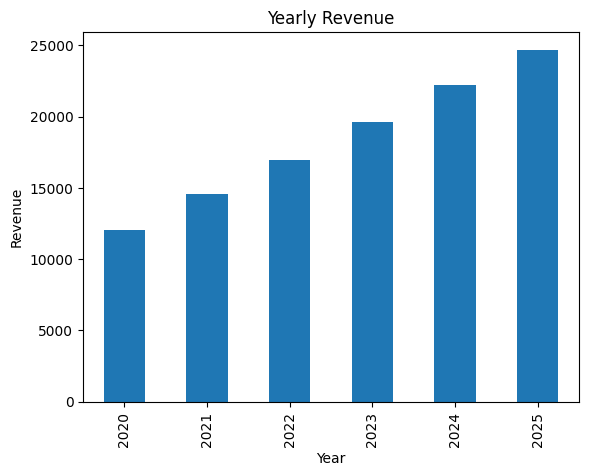

In [167]:
Yearly_Revenue.plot(kind="bar")
plt.xlabel("Year")
plt.ylabel("Revenue")
plt.title("Yearly Revenue")
plt.show()

In [113]:
Crop_Name_Revenue = df.groupby('Crop_Name')['Revenue'].sum()
Crop_Name_Revenue

,Revenue
Crop_Name,
Cotton Seed,46650.00
Gram,14967.73
Rape Seed,4557.92
Sunflower,43935.25


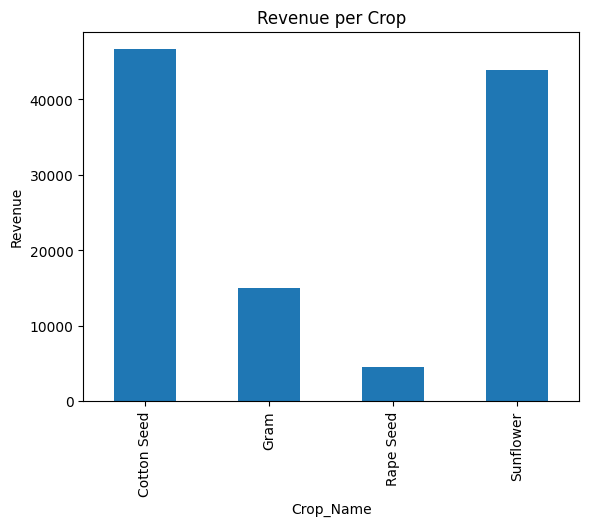

In [168]:
Crop_Name_Revenue.plot(kind="bar")
plt.xlabel("Crop_Name")
plt.ylabel("Revenue")
plt.title("Revenue per Crop")
plt.show()

In [114]:
Crop_Type_Revenue = df.groupby('Crop_Type')['Revenue'].sum()
Crop_Type_Revenue

,Revenue
Crop_Type,
Oilseed,95143.17
Pulse,14967.73


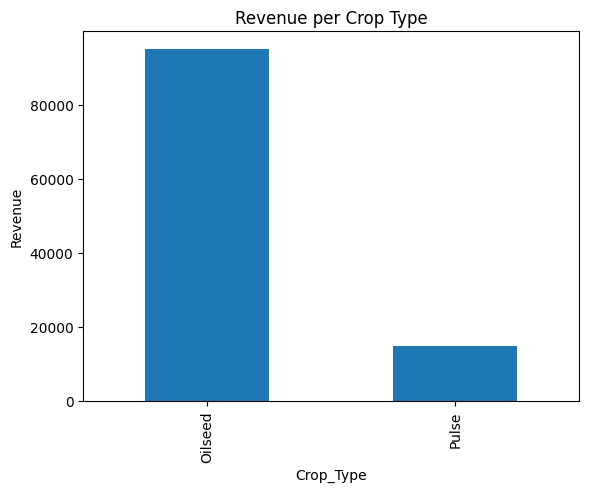

In [169]:
Crop_Type_Revenue.plot(kind="bar")
plt.xlabel("Crop_Type")
plt.ylabel("Revenue")
plt.title("Revenue per Crop Type")
plt.show()

In [115]:
Season_Revenue = df.groupby('Season')['Revenue'].sum()
Season_Revenue

,Revenue
Season,
Spring,43935.25
Summer,46650.00
Winter,19525.65


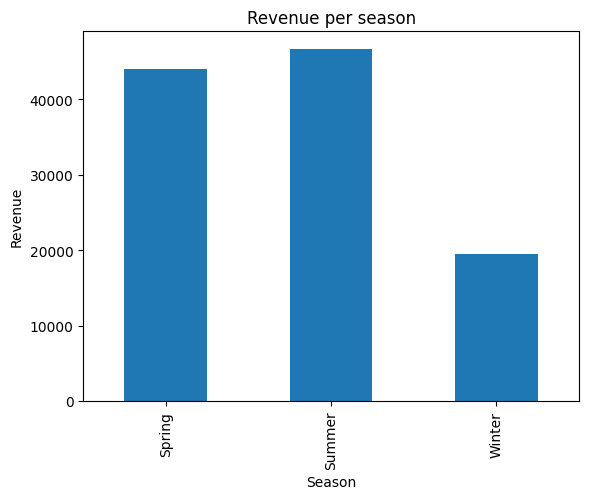

In [171]:
Season_Revenue.plot(kind="bar")
plt.xlabel("Season")
plt.ylabel("Revenue")
plt.title("Revenue per season")
plt.show()

In [116]:
soil_Type_Revenue = df.groupby('Soil_Type')['Revenue'].sum()
soil_Type_Revenue

,Revenue
Soil_Type,
Clay Loam,28318.845
Loamy,33499.370
Sandy,15852.000
Sandy Loam,32440.685


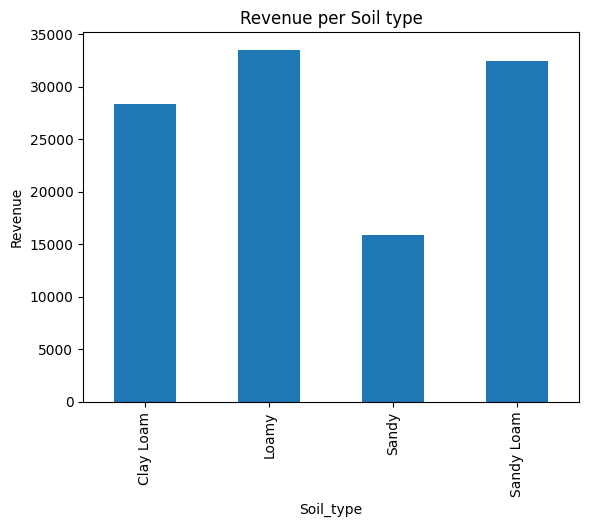

In [173]:
soil_Type_Revenue.plot(kind="bar")
plt.xlabel("Soil_type")
plt.ylabel("Revenue")
plt.title("Revenue per Soil type")
plt.show()

In [117]:
Export_Type_Revenue = df.groupby('Export_Status')['Revenue'].sum()
Export_Type_Revenue

,Revenue
Export_Status,
Exported,82482.335
Local Market,27628.565


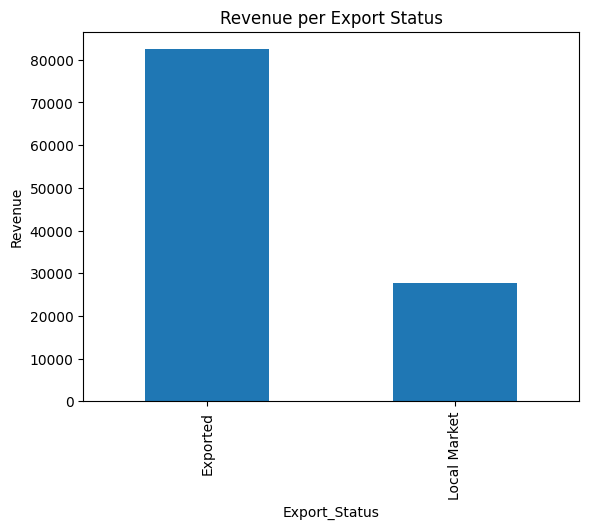

In [177]:
Export_Type_Revenue.plot(kind="bar")
plt.xlabel("Export_Status")
plt.ylabel("Revenue")
plt.title("Revenue per Export Status")
plt.show()

In [118]:
Quality_Grade_revenue = df.groupby('Quality_Grade')['Revenue'].sum()
Quality_Grade_revenue

,Revenue
Quality_Grade,
A,82482.335
B,27628.565


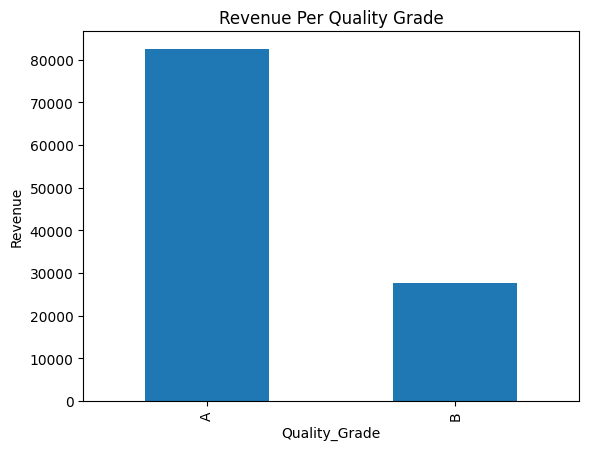

In [179]:
Quality_Grade_revenue.plot(kind="bar")
plt.xlabel("Quality_Grade")
plt.ylabel("Revenue")
plt.title("Revenue Per Quality Grade")
plt.show()

In [147]:
Temperature_Bucket_Revenue = df.groupby('Temperature_Bucket')['Revenue'].sum()
Temperature_Bucket_Revenue

,Revenue
Temperature_Bucket,
high,90585.25
low,19525.65


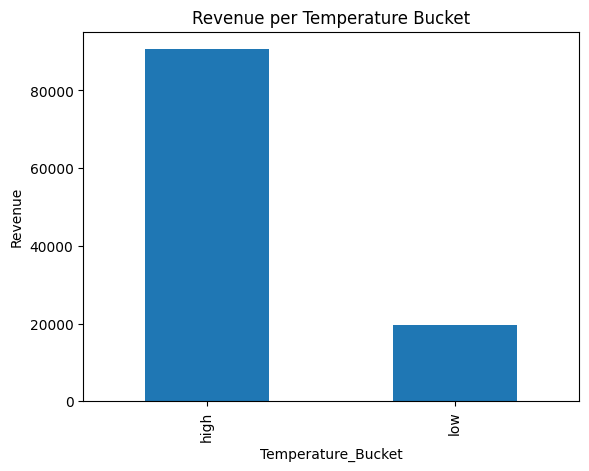

In [180]:
Temperature_Bucket_Revenue.plot(kind="bar")
plt.xlabel("Temperature_Bucket")
plt.ylabel("Revenue")
plt.title("Revenue per Temperature Bucket")
plt.show()

In [148]:
Rainfall_Bucket_Revenue = df.groupby('Rainfall_Bucket')['Revenue'].sum()
Rainfall_Bucket_Revenue

,Revenue
Rainfall_Bucket,
less,86194.45
more,23916.45


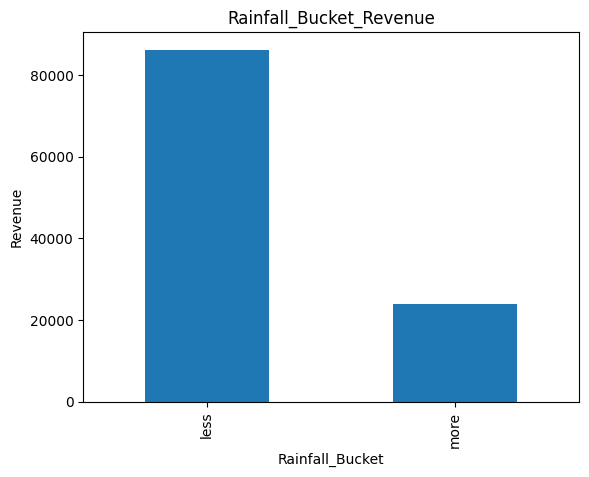

In [182]:
Rainfall_Bucket_Revenue.plot(kind="bar")
plt.xlabel("Rainfall_Bucket")
plt.ylabel("Revenue")
plt.title("Rainfall_Bucket_Revenue")
plt.show()

In [149]:
Irrigation_Bucket_Revenue = df.groupby('Irrigation_Bucket')['Revenue'].sum()
Irrigation_Bucket_Revenue

,Revenue
Irrigation_Bucket,
less,19525.65
medium,12842.10
more,77743.15


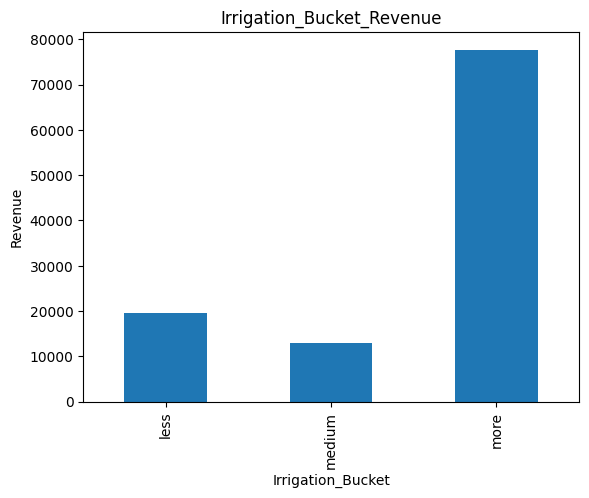

In [183]:
Irrigation_Bucket_Revenue.plot(kind="bar")
plt.xlabel("Irrigation_Bucket")
plt.ylabel("Revenue")
plt.title("Irrigation_Bucket_Revenue")
plt.show()

In [150]:
Purity_Bucket_Revenue = df.groupby('Purity_Bucket')['Revenue'].sum()
Purity_Bucket_Revenue

,Revenue
Purity_Bucket,
average,58237.40
maximum,38788.12
minimum,13085.38


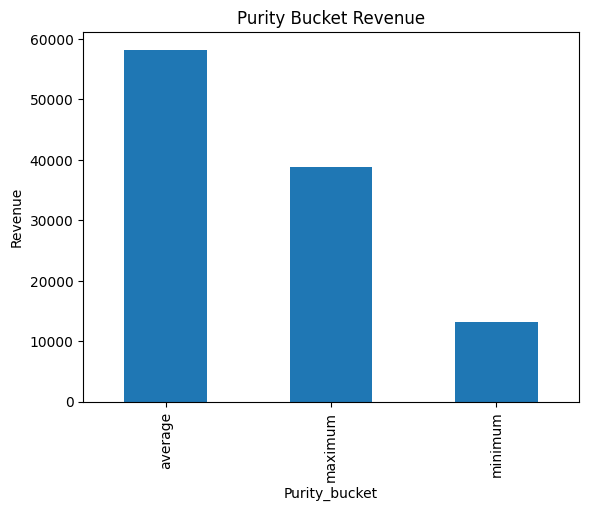

In [184]:
Purity_Bucket_Revenue.plot(kind="bar")
plt.xlabel("Purity_bucket")
plt.ylabel("Revenue")
plt.title("Purity Bucket Revenue")
plt.show()

In [119]:
# Group by Year and Crop_Name and sum the Revenue
yearly_crop_revenue = df.groupby(['Year', 'Crop_Name'])['Revenue'].sum().reset_index()
yearly_crop_revenue.sort_values(by=['Revenue','Year'], ascending=True)

,Year,Crop_Name,Revenue
2,2020,Rape Seed,505.440
6,2021,Rape Seed,596.160
10,2022,Rape Seed,692.480
14,2023,Rape Seed,809.760
18,2024,Rape Seed,931.680
22,2025,Rape Seed,1022.400
1,2020,Gram,1775.665
5,2021,Gram,2116.710
9,2022,Gram,2357.665
13,2023,Gram,2611.420


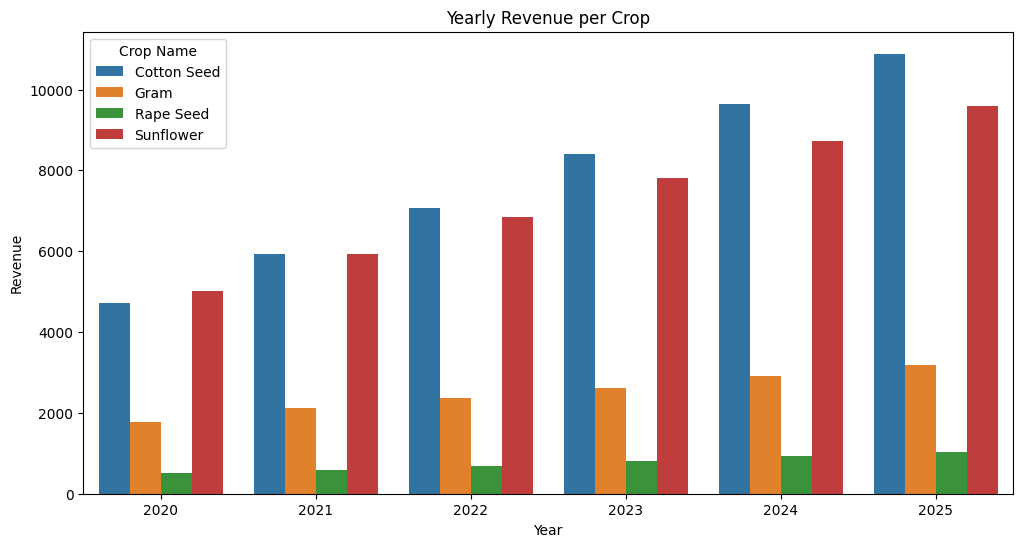

In [185]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Year', y='Revenue', hue='Crop_Name', data=yearly_crop_revenue)
plt.xlabel('Year')
plt.ylabel('Revenue')
plt.title('Yearly Revenue per Crop')
plt.legend(title='Crop Name')
plt.show()

In [120]:
# Group by Year and Crop_Type and sum the Revenue
yearly_crop_Type_revenue = df.groupby(['Year', 'Crop_Type'])['Revenue'].sum().reset_index()
yearly_crop_Type_revenue

,Year,Crop_Type,Revenue
0,2020,Oilseed,10233.970
1,2020,Pulse,1775.665
2,2021,Oilseed,12457.720
3,2021,Pulse,2116.710
4,2022,Oilseed,14611.960
5,2022,Pulse,2357.665
6,2023,Oilseed,17028.320
7,2023,Pulse,2611.420
8,2024,Oilseed,19302.660
9,2024,Pulse,2910.520


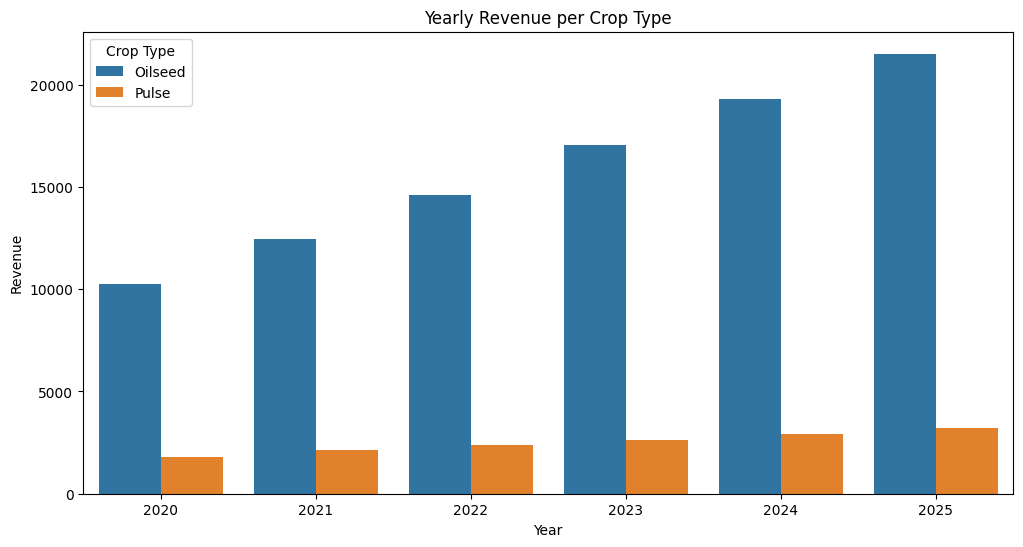

In [186]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Year', y='Revenue', hue='Crop_Type', data=yearly_crop_Type_revenue)
plt.xlabel('Year')
plt.ylabel('Revenue')
plt.title('Yearly Revenue per Crop Type')
plt.legend(title='Crop Type')
plt.show()

In [121]:
yearly_District_Name_revenue = df.groupby(['Year', 'District_Name'])['Revenue'].sum().reset_index()
yearly_District_Name_revenue

,Year,District_Name,Revenue
0,2020,Bahawalpur,1628.00
1,2020,Faisalabad,1462.50
2,2020,Gujranwala,585.00
3,2020,Gujrat,198.24
4,2020,Jhang,1023.12
...,...,...,...
61,2025,Multan,4602.00
62,2025,Okara,3630.80
63,2025,Sahiwal,1402.44
64,2025,Sialkot,1314.18


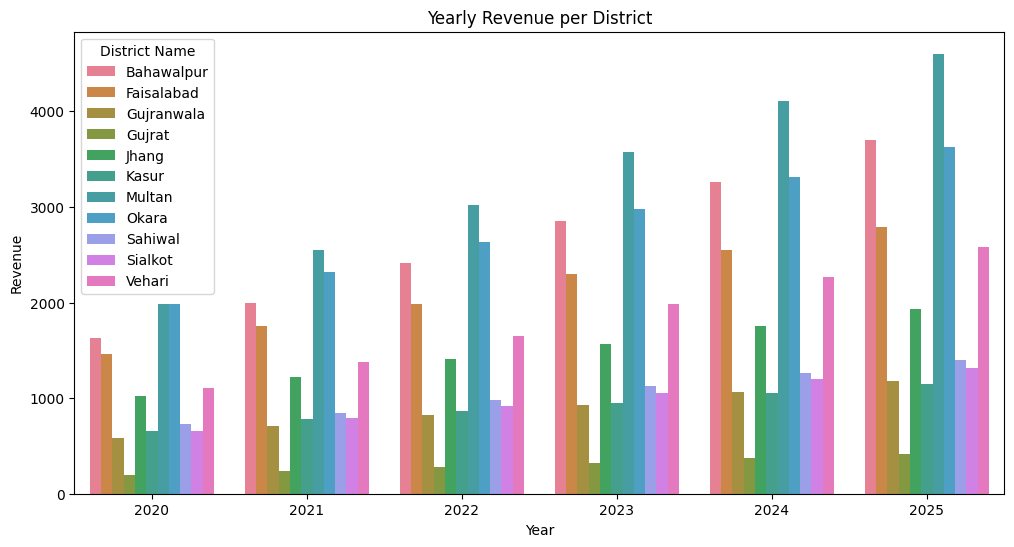

In [188]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Year', y='Revenue', hue='District_Name', data=yearly_District_Name_revenue)
plt.xlabel('Year')
plt.ylabel('Revenue')
plt.title('Yearly Revenue per District')
plt.legend(title='District Name')
plt.show()

In [122]:
yearly_Season_revenue = df.groupby(['Year', 'Season'])['Revenue'].sum().reset_index()
yearly_Season_revenue

,Year,Season,Revenue
0,2020,Spring,5013.530
1,2020,Summer,4715.000
2,2020,Winter,2281.105
3,2021,Spring,5936.560
4,2021,Summer,5925.000
5,2021,Winter,2712.870
6,2022,Spring,6842.480
7,2022,Summer,7077.000
8,2022,Winter,3050.145
9,2023,Spring,7807.560


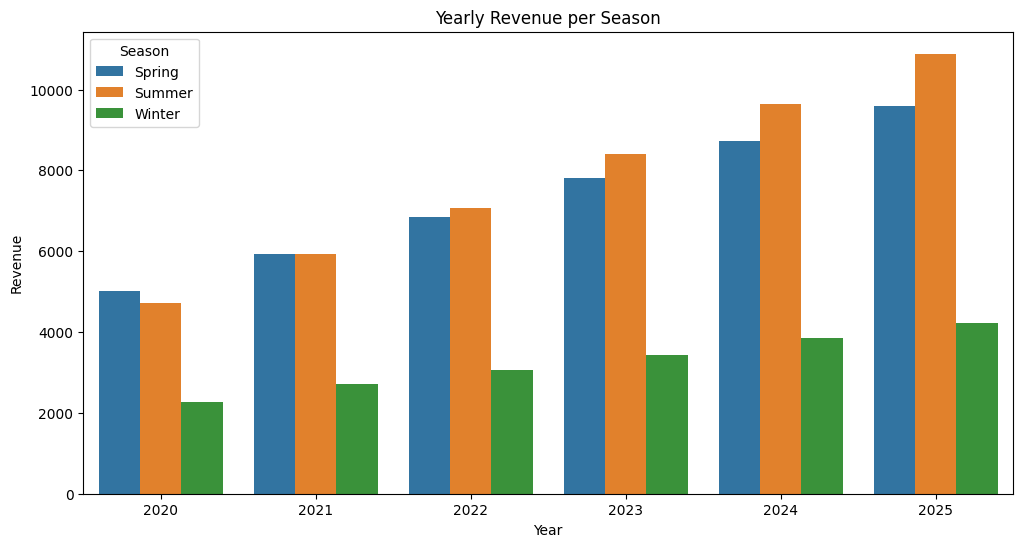

In [189]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Year', y='Revenue', hue='Season', data=yearly_Season_revenue)
plt.xlabel('Year')
plt.ylabel('Revenue')
plt.title('Yearly Revenue per Season')
plt.legend(title='Season')
plt.show()

In [123]:
yearly_Soil_Type_revenue = df.groupby(['Year', 'Soil_Type'])['Revenue'].sum().reset_index()
yearly_Soil_Type_revenue

,Year,Soil_Type,Revenue
0,2020,Clay Loam,2916.900
1,2020,Loamy,3709.160
2,2020,Sandy,1628.000
3,2020,Sandy Loam,3755.575
4,2021,Clay Loam,3685.060
5,2021,Loamy,4456.420
6,2021,Sandy,2000.000
7,2021,Sandy Loam,4432.950
8,2022,Clay Loam,4339.905
9,2022,Loamy,5185.970


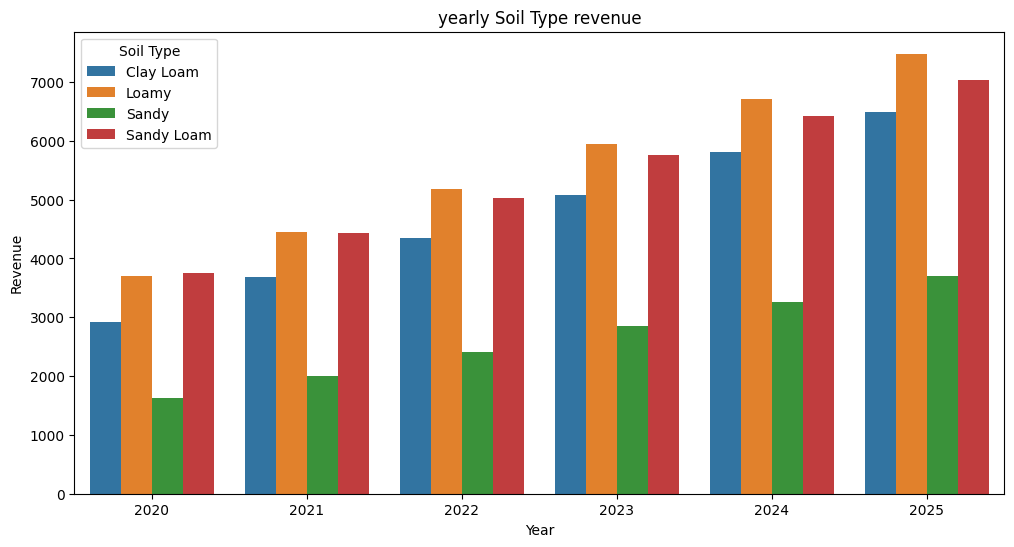

In [192]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Year', y='Revenue', hue='Soil_Type', data=yearly_Soil_Type_revenue)
plt.xlabel('Year')
plt.ylabel('Revenue')
plt.title('yearly Soil Type revenue')
plt.legend(title='Soil Type')
plt.show()

In [124]:
yearly_Export_Status_revenue = df.groupby(['Year', 'Export_Status'])['Revenue'].sum().reset_index()
yearly_Export_Status_revenue

,Year,Export_Status,Revenue
0,2020,Exported,9043.335
1,2020,Local Market,2966.300
2,2021,Exported,10984.410
3,2021,Local Market,3590.020
4,2022,Exported,12735.000
5,2022,Local Market,4234.625
6,2023,Exported,14704.460
7,2023,Local Market,4935.280
8,2024,Exported,16600.860
9,2024,Local Market,5612.320


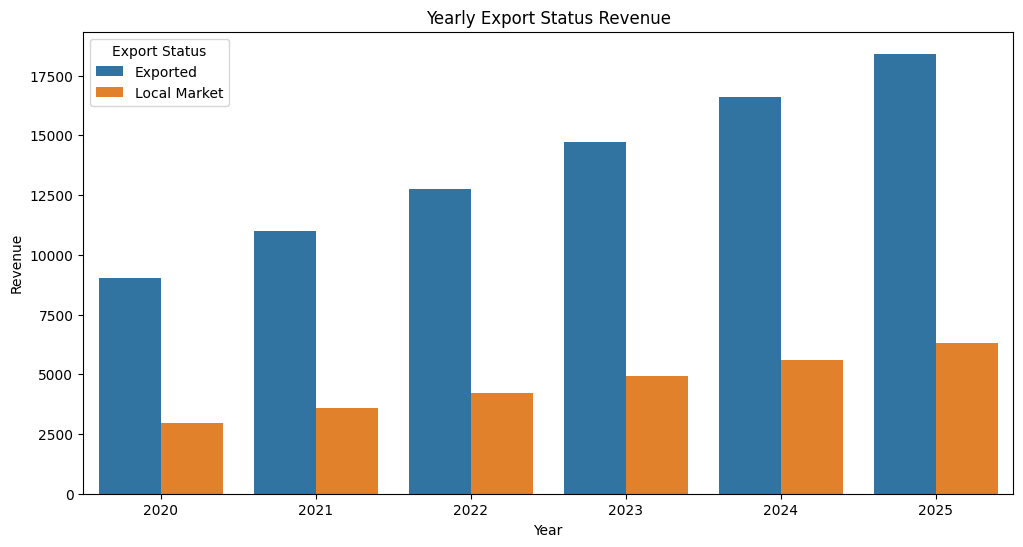

In [194]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Year', y='Revenue', hue='Export_Status', data=yearly_Export_Status_revenue)
plt.xlabel('Year')
plt.ylabel('Revenue')
plt.title('Yearly Export Status Revenue')
plt.legend(title='Export Status')
plt.show()

In [125]:
yearly_Quality_Grade_revenue = df.groupby(['Year', 'Quality_Grade'])['Revenue'].sum().reset_index()
yearly_Quality_Grade_revenue

,Year,Quality_Grade,Revenue
0,2020,A,9043.335
1,2020,B,2966.300
2,2021,A,10984.410
3,2021,B,3590.020
4,2022,A,12735.000
5,2022,B,4234.625
6,2023,A,14704.460
7,2023,B,4935.280
8,2024,A,16600.860
9,2024,B,5612.320


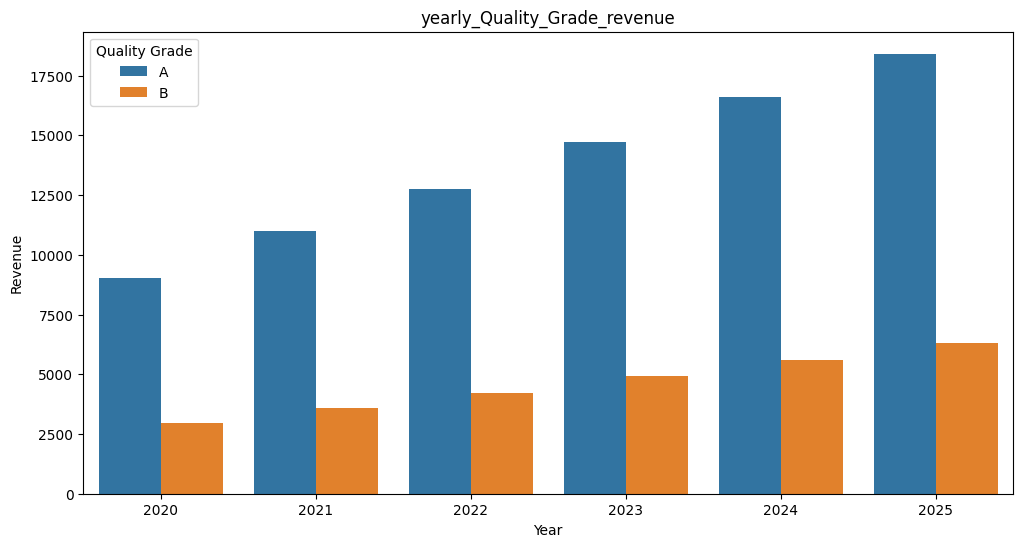

In [195]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Year', y='Revenue', hue='Quality_Grade', data=yearly_Quality_Grade_revenue)
plt.xlabel('Year')
plt.ylabel('Revenue')
plt.title('yearly_Quality_Grade_revenue')
plt.legend(title='Quality Grade')
plt.show()

In [152]:
Yearly_Temperature_Bucket_Revenue = df.groupby(['Year', 'Temperature_Bucket'])['Revenue'].sum().reset_index()
Yearly_Temperature_Bucket_Revenue

,Year,Temperature_Bucket,Revenue
0,2020,high,9728.530
1,2020,low,2281.105
2,2021,high,11861.560
3,2021,low,2712.870
4,2022,high,13919.480
5,2022,low,3050.145
6,2023,high,16218.560
7,2023,low,3421.180
8,2024,high,18370.980
9,2024,low,3842.200


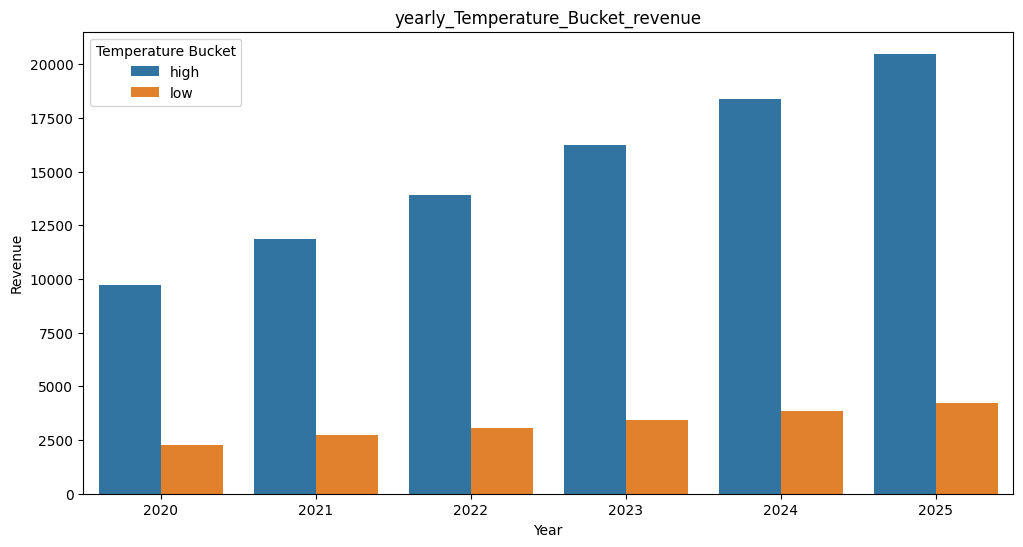

In [201]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Year', y='Revenue', hue='Temperature_Bucket', data=Yearly_Temperature_Bucket_Revenue)
plt.xlabel('Year')
plt.ylabel('Revenue')
plt.title('yearly_Temperature_Bucket_revenue')
plt.legend(title='Temperature Bucket')
plt.show()

In [155]:
Yearly_Rainfall_Bucket_Revenue = df.groupby(['Year', 'Rainfall_Bucket'])['Revenue'].sum().reset_index()
Yearly_Rainfall_Bucket_Revenue

,Year,Rainfall_Bucket,Revenue
0,2020,less,9728.530
1,2020,more,2281.105
2,2021,less,11861.560
3,2021,more,2712.870
4,2022,less,13919.480
5,2022,more,3050.145
6,2023,less,16218.560
7,2023,more,3421.180
8,2024,less,16273.380
9,2024,more,5939.800


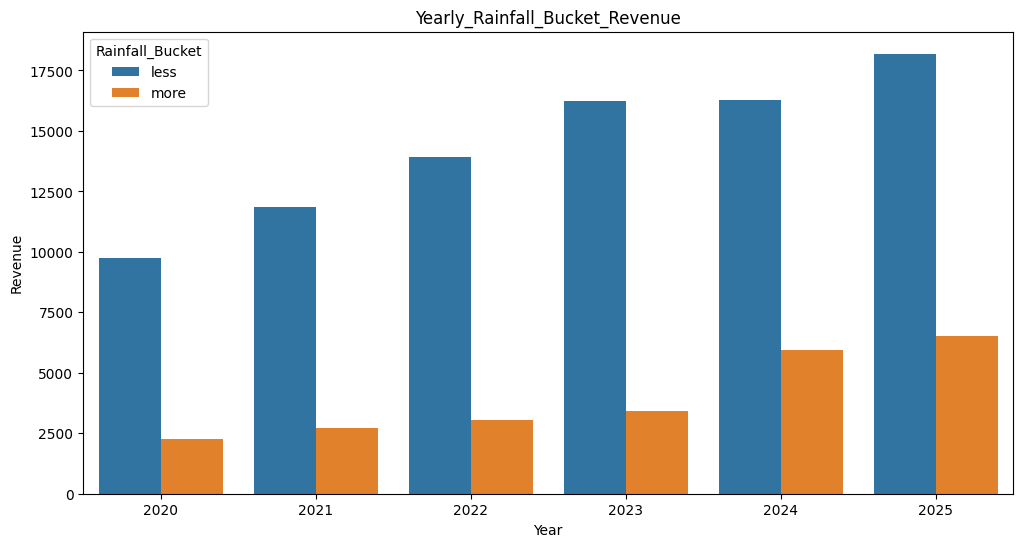

In [204]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Year', y='Revenue', hue='Rainfall_Bucket', data=Yearly_Rainfall_Bucket_Revenue)
plt.xlabel('Year')
plt.ylabel('Revenue')
plt.title('Yearly_Rainfall_Bucket_Revenue')
plt.legend(title='Rainfall_Bucket')
plt.show()

In [156]:
Yearly_Irrigation_Bucket_Revenue = df.groupby(['Year', 'Irrigation_Bucket'])['Revenue'].sum().reset_index()
Yearly_Irrigation_Bucket_Revenue

,Year,Irrigation_Bucket,Revenue
0,2020,less,2281.105
1,2020,medium,1462.500
2,2020,more,8266.030
3,2021,less,2712.870
4,2021,medium,1749.600
5,2021,more,10111.960
6,2022,less,3050.145
7,2022,medium,1989.000
8,2022,more,11930.480
9,2023,less,3421.180


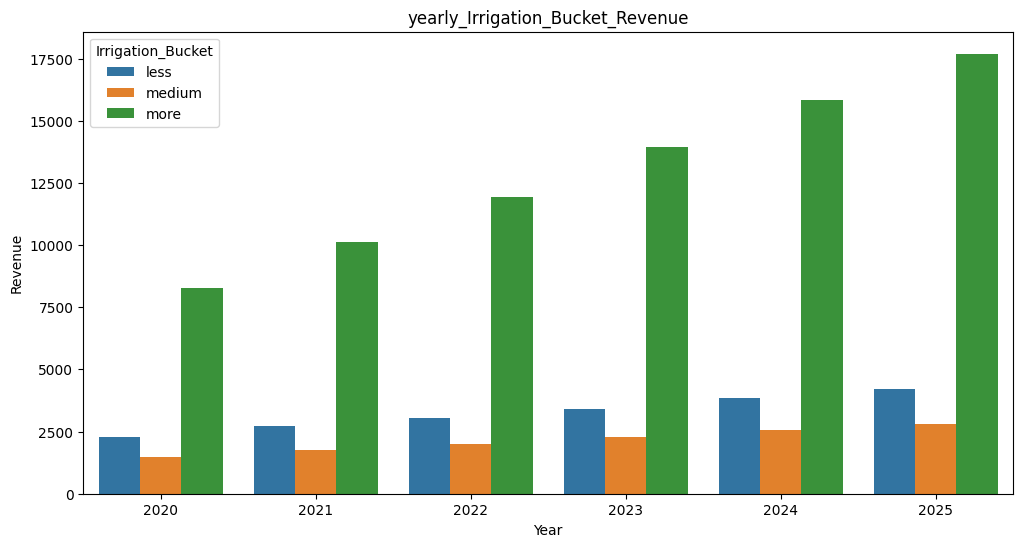

In [207]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Year', y='Revenue', hue='Irrigation_Bucket', data=Yearly_Irrigation_Bucket_Revenue)
plt.xlabel('Year')
plt.ylabel('Revenue')
plt.title('yearly_Irrigation_Bucket_Revenue')
plt.legend(title='Irrigation_Bucket')
plt.show()

In [157]:
Yearly_Purity_Bucket_Revenue = df.groupby(['Year', 'Purity_Bucket'])['Revenue'].sum().reset_index()
Yearly_Purity_Bucket_Revenue

,Year,Purity_Bucket,Revenue
0,2020,average,8934.375
1,2020,maximum,307.200
2,2020,minimum,2768.060
3,2021,average,10123.070
4,2021,maximum,2908.000
5,2021,minimum,1543.360
6,2022,average,10868.015
7,2022,maximum,4296.690
8,2022,minimum,1804.920
9,2023,average,11482.680


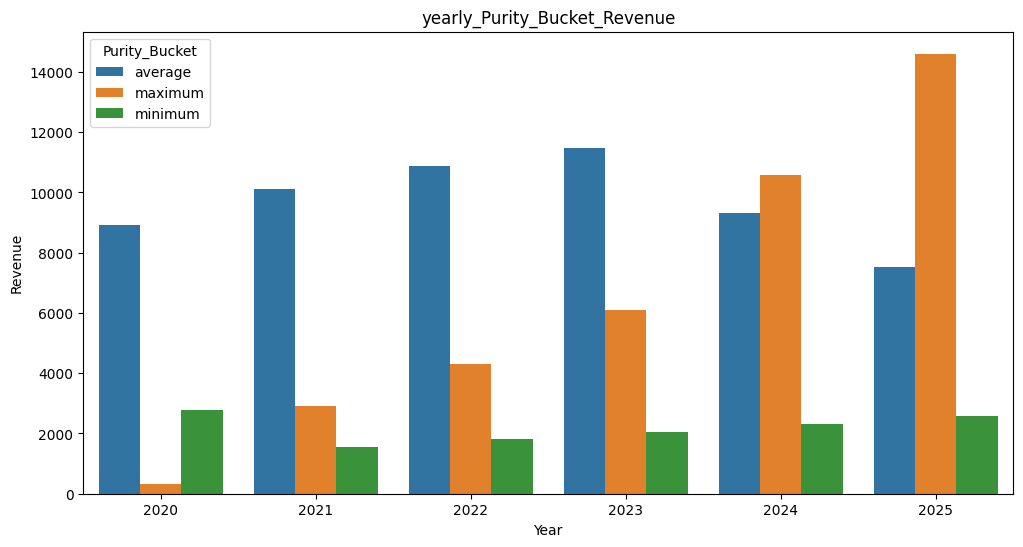

In [209]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Year', y='Revenue', hue='Purity_Bucket', data=Yearly_Purity_Bucket_Revenue)
plt.xlabel('Year')
plt.ylabel('Revenue')
plt.title('yearly_Purity_Bucket_Revenue')
plt.legend(title='Purity_Bucket')
plt.show()

In [164]:
Yearly_Yield_Per_Hectare_Bucket = df.groupby(['Year', 'Yield_Per_Hectare_Bucket'])['Revenue'].sum().reset_index()
Yearly_Yield_Per_Hectare_Bucket

,Year,Yield_Per_Hectare_Bucket,Revenue
0,2020,average,5013.530
1,2020,maximum,4715.000
2,2020,minimum,2281.105
3,2021,average,5936.560
4,2021,maximum,5925.000
5,2021,minimum,2712.870
6,2022,average,6842.480
7,2022,maximum,7077.000
8,2022,minimum,3050.145
9,2023,average,7807.560


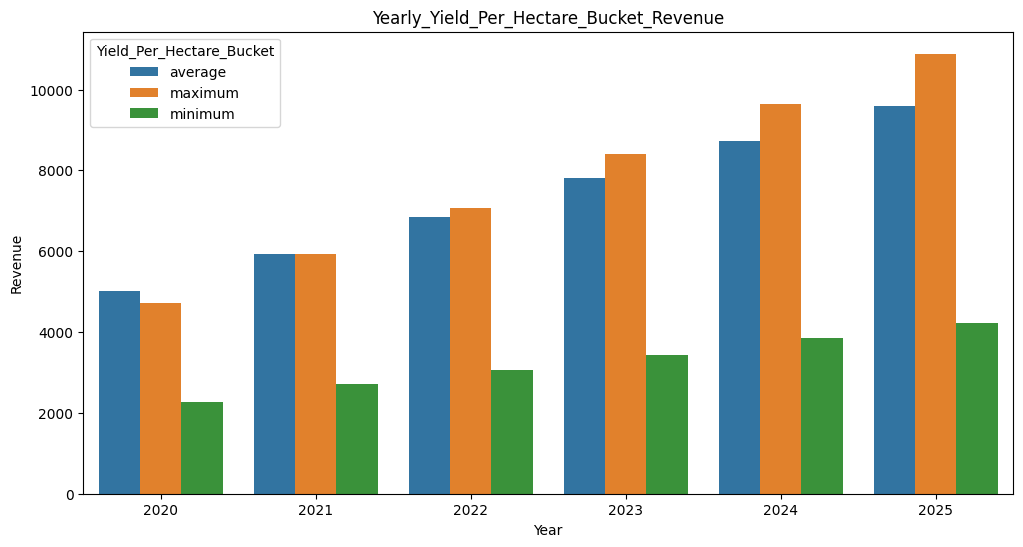

In [211]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Year', y='Revenue', hue='Yield_Per_Hectare_Bucket', data=Yearly_Yield_Per_Hectare_Bucket)
plt.xlabel('Year')
plt.ylabel('Revenue')
plt.title('Yearly_Yield_Per_Hectare_Bucket_Revenue')
plt.legend(title='Yield_Per_Hectare_Bucket')
plt.show()